In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
            
        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)
        
        if err < tol:
            return x_new, k + 1, errors
            
        x = x_new
        
    return x, max_iterations, errors

def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iterations):
        x_new = x.copy()

        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            return x_new, k + 1, errors

        x = x_new

    return x, max_iterations, errors

In [15]:
A = np.array([
    [3, -0.1, -0.2],
    [0.1, 7, -0.3],
    [0.3, -0.2, 10]
])

b = np.array([7.85, -19.3, 71.4])
x0 = np.array([0.0, 0.0, 0.0])
max_iter = 100

Tolerance: 0.001
Jacobi Iterations: 4
Gauss-Seidel Iterations: 4
Jacobi Solution: [ 3.0000225  -2.50000266  6.99998104]
Gauss-Seidel Solution: [ 3.00000035 -2.50000004  6.99999999]


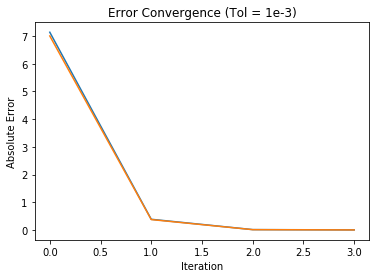

In [16]:
tol1 = 1e-3
sol_j1, it_j1, err_j1 = jacobi(A, b, x0, tol1, max_iter)
sol_gs1, it_gs1, err_gs1 = gauss_seidel(A, b, x0, tol1, max_iter)

print(f"Tolerance: {tol1}")
print(f"Jacobi Iterations: {it_j1}")
print(f"Gauss-Seidel Iterations: {it_gs1}")
print(f"Jacobi Solution: {sol_j1}")
print(f"Gauss-Seidel Solution: {sol_gs1}")

plt.figure()
plt.plot(err_j1, label='Jacobi')
plt.plot(err_gs1, label='Gauss-Seidel')
plt.title('Error Convergence (Tol = 1e-3)')
plt.ylabel('Absolute Error')
plt.xlabel('Iteration')
plt.show()

Both methods took the same amount of 4 iterations to converge. The lines for both methods mostly overlap, showing that they both converge rapidly

Tolerance: 1e-06
Jacobi Iterations: 7
Gauss-Seidel Iterations: 5
Jacobi Solution: [ 3.  -2.5  7. ]
Gauss-Seidel Solution: [ 3.  -2.5  7. ]


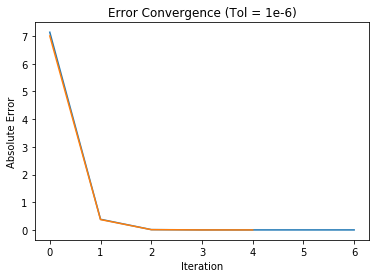

In [17]:
tol1 = 1e-6
sol_j1, it_j1, err_j1 = jacobi(A, b, x0, tol1, max_iter)
sol_gs1, it_gs1, err_gs1 = gauss_seidel(A, b, x0, tol1, max_iter)

print(f"Tolerance: {tol1}")
print(f"Jacobi Iterations: {it_j1}")
print(f"Gauss-Seidel Iterations: {it_gs1}")
print(f"Jacobi Solution: {sol_j1}")
print(f"Gauss-Seidel Solution: {sol_gs1}")

plt.figure()
plt.plot(err_j1, label='Jacobi')
plt.plot(err_gs1, label='Gauss-Seidel')
plt.title('Error Convergence (Tol = 1e-6)')
plt.ylabel('Absolute Error')
plt.xlabel('Iteration')
plt.show()

Gauss seidel converged faster in 5 iterations, while Jacobi took 7 iterations. The error curve overlaps for both again.

Tolerance: 1e-09
Jacobi Iterations: 9
Gauss-Seidel Iterations: 7
Jacobi Solution: [ 3.  -2.5  7. ]
Gauss-Seidel Solution: [ 3.  -2.5  7. ]


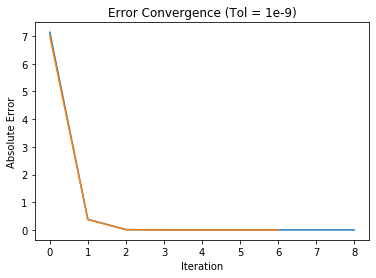

In [18]:
tol1 = 1e-9
sol_j1, it_j1, err_j1 = jacobi(A, b, x0, tol1, max_iter)
sol_gs1, it_gs1, err_gs1 = gauss_seidel(A, b, x0, tol1, max_iter)

print(f"Tolerance: {tol1}")
print(f"Jacobi Iterations: {it_j1}")
print(f"Gauss-Seidel Iterations: {it_gs1}")
print(f"Jacobi Solution: {sol_j1}")
print(f"Gauss-Seidel Solution: {sol_gs1}")

plt.figure()
plt.plot(err_j1, label='Jacobi')
plt.plot(err_gs1, label='Gauss-Seidel')
plt.title('Error Convergence (Tol = 1e-9)')
plt.ylabel('Absolute Error')
plt.xlabel('Iteration')
plt.show()

Gauss seidel converged faster in 7 iterations, while Jacobi took 9 iterations. The error curves completely overlap

Decreasing the tolerance means that the maximum absolute error between iterations must cross a much smaller threshold. Because the algorithms only reduce the error by a small amount per step, hitting a tighter boundary requires many more iterations. 